Model file found at: /home/nishioka/GNN/GNNmodel/GATModel_final_20241001_170033.pth
Predicted vs True Labels (First 10 Samples):
Predicted: 0.0008, True: 0.0000
Predicted: 0.0009, True: 0.0000
Predicted: 0.0013, True: 0.0000
Predicted: 0.0019, True: 0.0000
Predicted: 0.0018, True: 0.0000
Predicted: 0.0015, True: 0.0000
Predicted: 0.0015, True: 0.0000
Predicted: 0.0015, True: 0.0000
Predicted: 0.0015, True: 0.0000
Predicted: 0.0016, True: 0.0000

Output Stats: min=-0.0043, max=0.0379, mean=0.0072
Label Stats: min=0.0000, max=0.0000, mean=0.0000


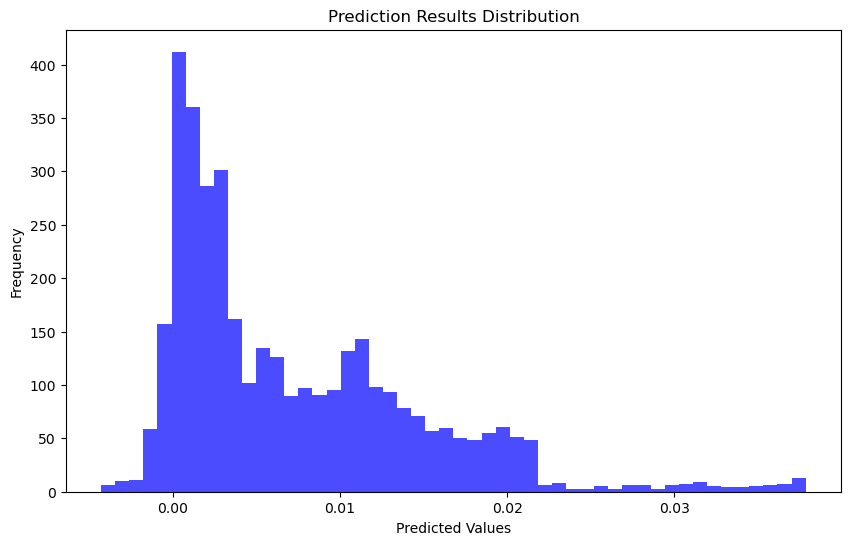

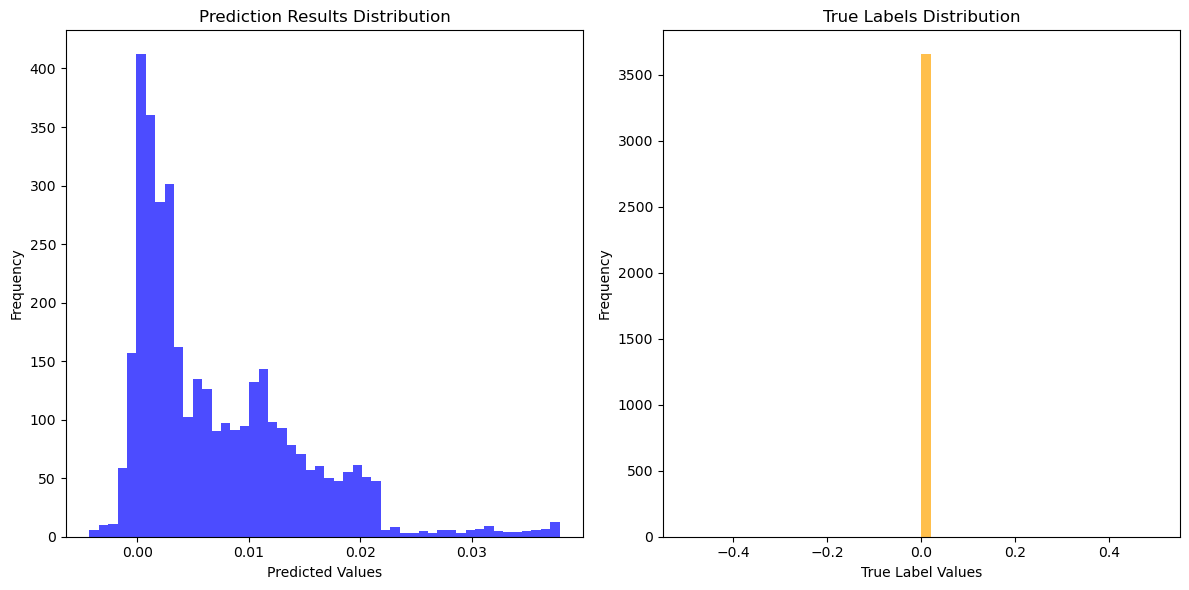

In [6]:
import os
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import matplotlib.pyplot as plt

# デバイスをCPUに固定
device = torch.device("cpu")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin.weight)

# GATモデルの定義
class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=64):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  # GATConv使用
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  # 変更
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels)  # 変更
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        return self.fc_defect(x)

# モデルファイルが存在しているか確認
model_path = '/home/nishioka/GNN/GNNmodel/GATModel_final_20241001_170033.pth'
if os.path.exists(model_path):
    print(f"Model file found at: {model_path}")
else:
    print(f"Model file not found: {model_path}")

# 学習済みモデルのロード
def load_trained_model(model_path):
    model = GATModel()
    model.load_state_dict(torch.load(model_path, map_location=device))  # CPUにマップしてロード
    model.to(device)  # モデルをCPUに移動
    model.eval()  # 評価モードに設定
    return model

# モデルのパラメータを確認する
def check_model_parameters(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Shape: {param.shape}, Values: {param[:2]}")  # パラメータの形状と最初の2つの値を表示

# データの準備
def prepare_test_data(file_path, edge_path):
    # 入力データの読み込み (x, y, z 座標と主応力データ)
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    stress_values = np.load(file_path)  # 主応力データ

    # エッジ情報の読み込み
    edges = np.load(edge_path)

    # ノード特徴量 (x, y, z, 主応力) を結合
    node_features = np.vstack((x_coords, y_coords, z_coords, stress_values)).T

    # データを PyTorch のテンソルに変換
    input_data = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)

    # torch_geometric の Data オブジェクトに変換し、CPUに移動
    data = Data(x=input_data, edge_index=edge_index).to(device)
    return data

# 予測を実行し、結果を表示する関数
def predict(model, data):
    model.eval()
    with torch.no_grad():  # 勾配計算を無効にして予測
        output = model(data)
    return output

# 予測結果と教師データの比較
def compare_with_labels(output, label_file_path):
    # 出力と教師データを比較
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy()

    # 予測結果と教師データの最初の10個を比較表示
    print("Predicted vs True Labels (First 10 Samples):")
    for i in range(10):
        print(f"Predicted: {output_np[i][0]:.4f}, True: {true_labels[i]:.4f}")

    # 統計情報を表示
    print(f"\nOutput Stats: min={output_np.min():.4f}, max={output_np.max():.4f}, mean={output_np.mean():.4f}")
    print(f"Label Stats: min={true_labels.min():.4f}, max={true_labels.max():.4f}, mean={true_labels.mean():.4f}")

# 予測結果を表示・プロット
def plot_predictions(output):
    output_np = output.detach().cpu().numpy()
    plt.figure(figsize=(10, 6))
    plt.hist(output_np, bins=50, color='blue', alpha=0.7)
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.show()

# 予測結果と教師データの分布をヒストグラムで可視化
def plot_predictions_and_labels(output, label_file_path):
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy()

    plt.figure(figsize=(12, 6))

    # 予測結果のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(output_np, bins=50, color='blue', alpha=0.7)
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")

    # 教師データのヒストグラム
    plt.subplot(1, 2, 2)
    plt.hist(true_labels, bins=50, color='orange', alpha=0.7)
    plt.title("True Labels Distribution")
    plt.xlabel("True Label Values")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# メイン関数
def main():
    model_path = '/home/nishioka/GNN/GNNmodel/GATModel_final_20241001_170033.pth'
    file_path = "/home/nishioka/GNN/Defect_4x4_Standardized1/Standardized1_Defect4x4_ELNOD_L19B45.npy"
    # file_path = "/home/nishioka/GNN/Defect_4x4_Standardized1/0Standardized1_nodefect_4x4_ElNOD.npy"
    # label_file_path = "/home/nishioka/GNN/DefectLabels_4x4_test1/0DefectLabel_nodefect1.npy"
    label_file_path = "/home/nishioka/GNN/DefectLabels_4x4_test1/DefectLabel_L19B45.npy"
    edge_path = "/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy"
    
    # モデルのロード
    model = load_trained_model(model_path)

    # テストデータの準備
    data = prepare_test_data(file_path, edge_path)

    # 予測を実行
    output = predict(model, data)

    # 予測結果の表示
    compare_with_labels(output, label_file_path)

    # プロット表示
    plot_predictions(output)
    plot_predictions_and_labels(output, label_file_path)

if __name__ == "__main__":
    main()

Model file found at: /home/nishioka/GNN/GNNmodel/GATModel_final_20241003_135445.pth
Predicted vs True Labels (First 10 Samples):
Predicted: 0.0041, True: 0.0000
Predicted: 0.0041, True: 0.0000
Predicted: 0.0039, True: 0.0000
Predicted: 0.0034, True: 0.0000
Predicted: 0.0025, True: 0.0000
Predicted: 0.0016, True: 0.0000
Predicted: 0.0010, True: 0.0000
Predicted: 0.0006, True: 0.0000
Predicted: 0.0003, True: 0.0000
Predicted: 0.0002, True: 0.0000

Output Stats: min=0.0000, max=0.0041, mean=0.0000
Label Stats: min=0.0000, max=0.9500, mean=0.0068


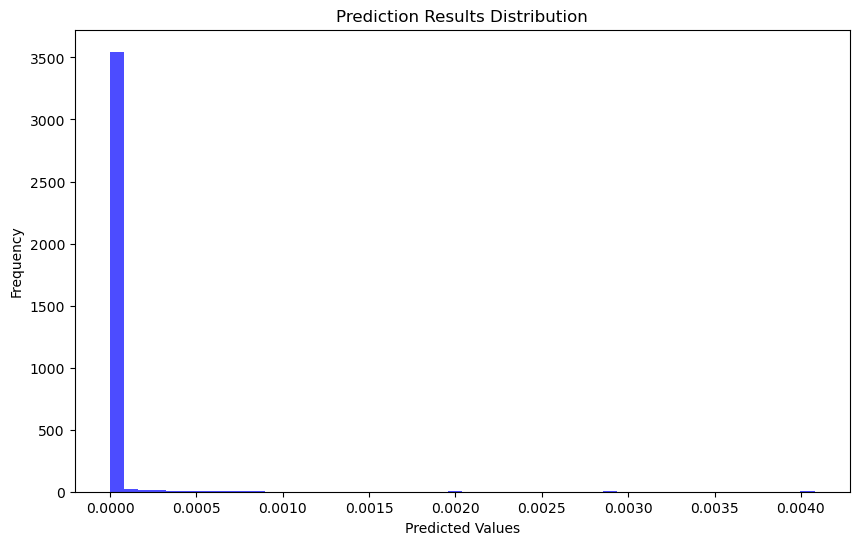

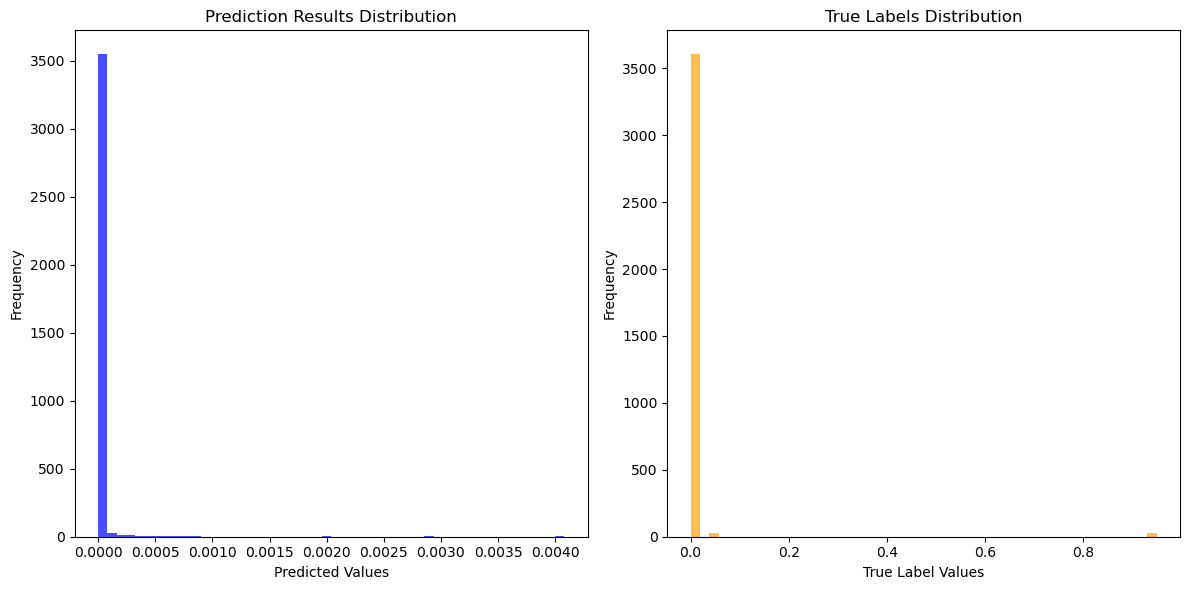

In [2]:
import os
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import matplotlib.pyplot as plt

# デバイスをCPUに固定
device = torch.device("cpu")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin.weight)

class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=128):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels * 4, heads=4)  
        self.conv4 = GATConv(hidden_channels * 16, hidden_channels, heads=4)  
        self.conv5 = GATConv(hidden_channels * 4, hidden_channels)  # 新しい5層目
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = F.relu(self.conv5(x, edge_index))  # 新しい5層目
        x = self.fc_defect(x)  
        return torch.sigmoid(x)  

# モデルファイルが存在しているか確認
model_path = '/home/nishioka/GNN/GNNmodel/GATModel_final_20241003_135445.pth'
if os.path.exists(model_path):
    print(f"Model file found at: {model_path}")
else:
    print(f"Model file not found: {model_path}")

# 学習済みモデルのロード
def load_trained_model(model_path):
    model = GATModel()
    model.load_state_dict(torch.load(model_path, map_location=device))  # CPUにマップしてロード
    model.to(device)  # モデルをCPUに移動
    model.eval()  # 評価モードに設定
    return model

# モデルのパラメータを確認する
def check_model_parameters(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Shape: {param.shape}, Values: {param[:2]}")  # パラメータの形状と最初の2つの値を表示

# データの準備
def prepare_test_data(file_path, edge_path):
    # 入力データの読み込み (x, y, z 座標と主応力データ)
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    stress_values = np.load(file_path)  # 主応力データ

    # エッジ情報の読み込み
    edges = np.load(edge_path)

    # ノード特徴量 (x, y, z, 主応力) を結合
    node_features = np.vstack((x_coords, y_coords, z_coords, stress_values)).T

    # データを PyTorch のテンソルに変換
    input_data = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)

    # torch_geometric の Data オブジェクトに変換し、CPUに移動
    data = Data(x=input_data, edge_index=edge_index).to(device)
    return data

# 予測を実行し、結果を表示する関数
def predict(model, data):
    model.eval()
    with torch.no_grad():  # 勾配計算を無効にして予測
        output = model(data)
    return output

# 予測結果と教師データの比較
def compare_with_labels(output, label_file_path):
    # 出力と教師データを比較
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy()

    # 予測結果と教師データの最初の10個を比較表示
    print("Predicted vs True Labels (First 10 Samples):")
    for i in range(10):
        print(f"Predicted: {output_np[i][0]:.4f}, True: {true_labels[i]:.4f}")

    # 統計情報を表示
    print(f"\nOutput Stats: min={output_np.min():.4f}, max={output_np.max():.4f}, mean={output_np.mean():.4f}")
    print(f"Label Stats: min={true_labels.min():.4f}, max={true_labels.max():.4f}, mean={true_labels.mean():.4f}")

# 予測結果を表示・プロット
def plot_predictions(output):
    output_np = output.detach().cpu().numpy()
    plt.figure(figsize=(10, 6))
    plt.hist(output_np, bins=50, color='blue', alpha=0.7)
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.show()

# 予測結果と教師データの分布をヒストグラムで可視化
def plot_predictions_and_labels(output, label_file_path):
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy()

    plt.figure(figsize=(12, 6))

    # 予測結果のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(output_np, bins=50, color='blue', alpha=0.7)
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")

    # 教師データのヒストグラム
    plt.subplot(1, 2, 2)
    plt.hist(true_labels, bins=50, color='orange', alpha=0.7)
    plt.title("True Labels Distribution")
    plt.xlabel("True Label Values")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# メイン関数
def main():
    model_path = '/home/nishioka/GNN/GNNmodel/GATModel_best_20241003_171152.pth'
    file_path = "/home/nishioka/GNN/Defect_4x4_Standardized1/Standardized1_Defect4x4_ELNOD_L19B45.npy"
    # file_path = "/home/nishioka/GNN/Defect_4x4_Standardized1/0Standardized1_nodefect_4x4_ElNOD.npy"
    # label_file_path = "/home/nishioka/GNN/DefectLabels_4x4_test1/0DefectLabel_nodefect1.npy"
    label_file_path = "/home/nishioka/GNN/DefectLabels_4x4_test1/DefectLabel_L19B45.npy"
    edge_path = "/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy"
    
    # モデルのロード
    model = load_trained_model(model_path)

    # テストデータの準備
    data = prepare_test_data(file_path, edge_path)

    # 予測を実行
    output = predict(model, data)

    # 予測結果の表示
    compare_with_labels(output, label_file_path)

    # プロット表示
    plot_predictions(output)
    plot_predictions_and_labels(output, label_file_path)

if __name__ == "__main__":
    main()

Model file found at: /home/nishioka/GNN/GNNmodel/GATModel_final_20241003_135445.pth
Predicted vs True Labels (First 10 Samples):
Predicted: 0.0041, True: 0.0000
Predicted: 0.0041, True: 0.0000
Predicted: 0.0039, True: 0.0000
Predicted: 0.0034, True: 0.0000
Predicted: 0.0025, True: 0.0000
Predicted: 0.0016, True: 0.0000
Predicted: 0.0010, True: 0.0000
Predicted: 0.0006, True: 0.0000
Predicted: 0.0003, True: 0.0000
Predicted: 0.0002, True: 0.0000

Output Stats: min=0.0000, max=0.0041, mean=0.0000
Label Stats: min=0.0000, max=0.9500, mean=0.0068


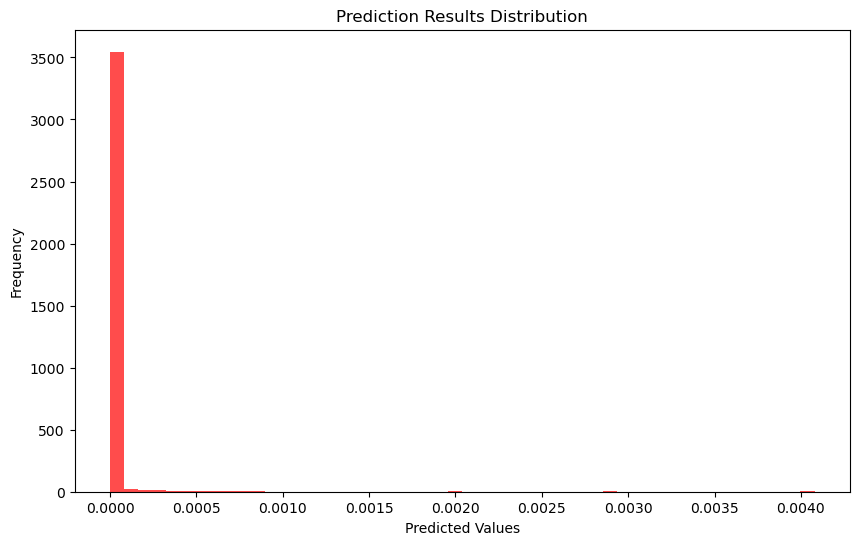

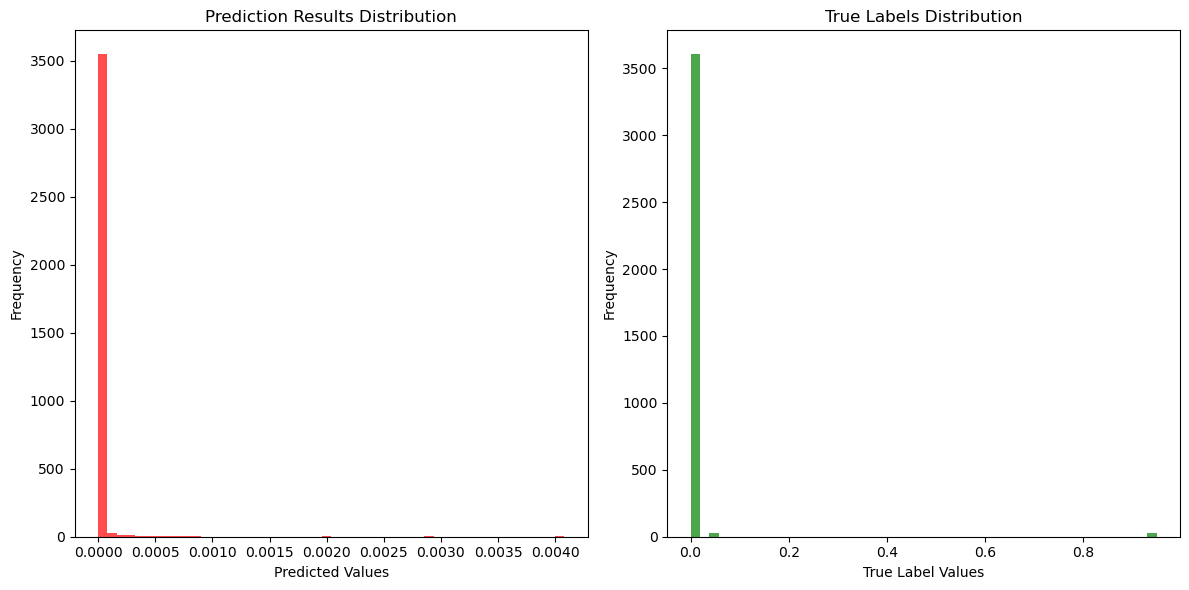

Predictions saved to /home/nishioka/GNN/predictiondatavtk/GATModel_predictions_L19B45.npy with shape (3654,)


In [3]:
import os
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import matplotlib.pyplot as plt

# デバイスをCPUに固定
device = torch.device("cpu")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin.weight)

class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=128):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels * 4, heads=4)  
        self.conv4 = GATConv(hidden_channels * 16, hidden_channels, heads=4)  
        self.conv5 = GATConv(hidden_channels * 4, hidden_channels)  # 新しい5層目
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = F.relu(self.conv5(x, edge_index))  # 新しい5層目
        x = self.fc_defect(x)  
        return torch.sigmoid(x)  

# モデルファイルが存在しているか確認
model_path = '/home/nishioka/GNN/GNNmodel/GATModel_final_20241003_135445.pth'
if os.path.exists(model_path):
    print(f"Model file found at: {model_path}")
else:
    print(f"Model file not found: {model_path}")

# 学習済みモデルのロード
def load_trained_model(model_path):
    model = GATModel()
    model.load_state_dict(torch.load(model_path, map_location=device))  # CPUにマップしてロード
    model.to(device)  # モデルをCPUに移動
    model.eval()  # 評価モードに設定
    return model

# モデルのパラメータを確認する
def check_model_parameters(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Shape: {param.shape}, Values: {param[:2]}")  # パラメータの形状と最初の2つの値を表示

# データの準備
def prepare_test_data(file_path, edge_path):
    # 入力データの読み込み (x, y, z 座標と主応力データ)
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    stress_values = np.load(file_path)  # 主応力データ

    # エッジ情報の読み込み
    edges = np.load(edge_path)

    # ノード特徴量 (x, y, z, 主応力) を結合
    node_features = np.vstack((x_coords, y_coords, z_coords, stress_values)).T

    # データを PyTorch のテンソルに変換
    input_data = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)

    # torch_geometric の Data オブジェクトに変換し、CPUに移動
    data = Data(x=input_data, edge_index=edge_index).to(device)
    return data

# 予測を実行し、結果を表示する関数
def predict(model, data):
    model.eval()
    with torch.no_grad():  # 勾配計算を無効にして予測
        output = model(data)
    return output

# 予測結果と教師データの比較
def compare_with_labels(output, label_file_path):
    # 出力と教師データを比較
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy()

    # 予測結果と教師データの最初の10個を比較表示
    print("Predicted vs True Labels (First 10 Samples):")
    for i in range(10):
        print(f"Predicted: {output_np[i][0]:.4f}, True: {true_labels[i]:.4f}")

    # 統計情報を表示
    print(f"\nOutput Stats: min={output_np.min():.4f}, max={output_np.max():.4f}, mean={output_np.mean():.4f}")
    print(f"Label Stats: min={true_labels.min():.4f}, max={true_labels.max():.4f}, mean={true_labels.mean():.4f}")

# 予測結果を表示・プロット
def plot_predictions(output):
    output_np = output.detach().cpu().numpy()
    plt.figure(figsize=(10, 6))
    plt.hist(output_np, bins=50, color='red', alpha=0.7)
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.show()

# 予測結果と教師データの分布をヒストグラムで可視化
def plot_predictions_and_labels(output, label_file_path):
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy()

    plt.figure(figsize=(12, 6))

    # 予測結果のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(output_np, bins=50, color='red', alpha=0.7)
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")

    # 教師データのヒストグラム
    plt.subplot(1, 2, 2)
    plt.hist(true_labels, bins=50, color='green', alpha=0.7)
    plt.title("True Labels Distribution")
    plt.xlabel("True Label Values")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# 予測結果を1次元配列として保存する関数
def save_predictions(output, save_path):
    """
    予測結果を指定されたパスに1次元配列として .npy ファイルに保存する関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - save_path (str): 保存先のファイルパス。
    """
    try:
        # 保存先のディレクトリを取得
        directory = os.path.dirname(save_path)
        
        # ディレクトリが存在しない場合は作成
        if not os.path.exists(directory):
            os.makedirs(directory)
            print(f"Created directory: {directory}")
        
        # テンソルを NumPy 配列に変換し、1次元にリシェイプ
        output_np = output.detach().cpu().numpy().flatten()
        
        # .npy ファイルとして保存
        np.save(save_path, output_np)
        
        print(f"Predictions saved to {save_path} with shape {output_np.shape}")
    except Exception as e:
        print(f"Failed to save predictions: {e}")

# メイン関数
def main():
    model_path = '/home/nishioka/GNN/GNNmodel/GATModel_best_20241003_171152.pth'
    file_path = "/home/nishioka/GNN/Defect_4x4_Standardized1/Standardized1_Defect4x4_ELNOD_L19B45.npy"
    label_file_path = "/home/nishioka/GNN/DefectLabels_4x4_test1/DefectLabel_L19B45.npy"
    edge_path = "/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy"
    
    # モデルのロード
    model = load_trained_model(model_path)

    # テストデータの準備
    data = prepare_test_data(file_path, edge_path)

    # 予測を実行
    output = predict(model, data)

    # 予測結果の表示
    compare_with_labels(output, label_file_path)

    # プロット表示
    plot_predictions(output)
    plot_predictions_and_labels(output, label_file_path)

    # 予測結果を1次元配列として保存
    save_path = "/home/nishioka/GNN/predictiondatavtk/GATModel_predictions_L19B45.npy"  # 保存先のパスを指定
    save_predictions(output, save_path)

if __name__ == "__main__":
    main()